In [1]:
# ─────────────────────────────────────────────
# CELL 1 — Mount Google Drive + verify datasets
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# base paths
BASE    = '/content/drive/MyDrive/honeycloud'
DATA    = f'{BASE}/datasets'
MODELS  = f'{BASE}/models'

# create models folder if it doesn't exist
os.makedirs(MODELS, exist_ok=True)

# verify all 4 files exist
files = {
    'Dionaea'          : f'{DATA}/dionaea/dionaeaClean2.csv',
    'AWS Geo'          : f'{DATA}/aws/AWS_Honeypot_marx-geo.csv',
    'Hornet40 Summary' : f'{DATA}/hornet40/Hornet40-Dataset-Summary-Table.csv',
    'Hornet40 Hourly'  : f'{DATA}/hornet40/hornet40-traffic-per-honeypot-hourly-comparative.csv',
}

print("Checking datasets...")
all_good = True
for name, path in files.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "NOT FOUND"
    status = "✅" if exists else "❌"
    print(f"  {status}  {name:<20} {size}")
    if not exists:
        all_good = False

print()
if all_good:
    print("✅ All datasets found. Ready to build.")
else:
    print("❌ Some files missing — check your Drive folder structure.")

Mounted at /content/drive
Checking datasets...
  ✅  Dionaea              1994.4 KB
  ✅  AWS Geo              47709.7 KB
  ✅  Hornet40 Summary     1.8 KB
  ✅  Hornet40 Hourly      58.3 KB

✅ All datasets found. Ready to build.


DATASET OVERVIEW

── Dionaea ──
   Rows: 27,529  |  Columns: 7
   Columns: ['protocol', 'transport', 'type', 'dst_port', 'src_ip', 'src_port', 'timestamp']
   Sample:
     protocol transport  type        dst_port  src_ip                     src_port  timestamp
smbd      tcp    accept   445   62.74.213.178    1176   2022-05-07T15:08:48.091297        NaN
smbd      tcp    accept   445   62.74.213.178    1202   2022-05-07T15:08:48.869184        NaN

── AWS Geo ──
   Rows: 451,581  |  Columns: 16
   Columns: ['datetime', 'host', 'src', 'proto', 'type', 'spt', 'dpt', 'srcstr', 'cc', 'country', 'locale', 'localeabbr', 'postalcode', 'latitude', 'longitude', 'Unnamed: 15']
   Sample:
       datetime            host         src proto  type     spt     dpt          srcstr  cc  country         locale localeabbr postalcode  latitude  longitude  Unnamed: 15
0  3/3/13 21:53  groucho-oregon  1032051418   TCP   NaN  6000.0  1433.0  61.131.218.218  CN    China  Jiangxi Sheng         36        NaN     28

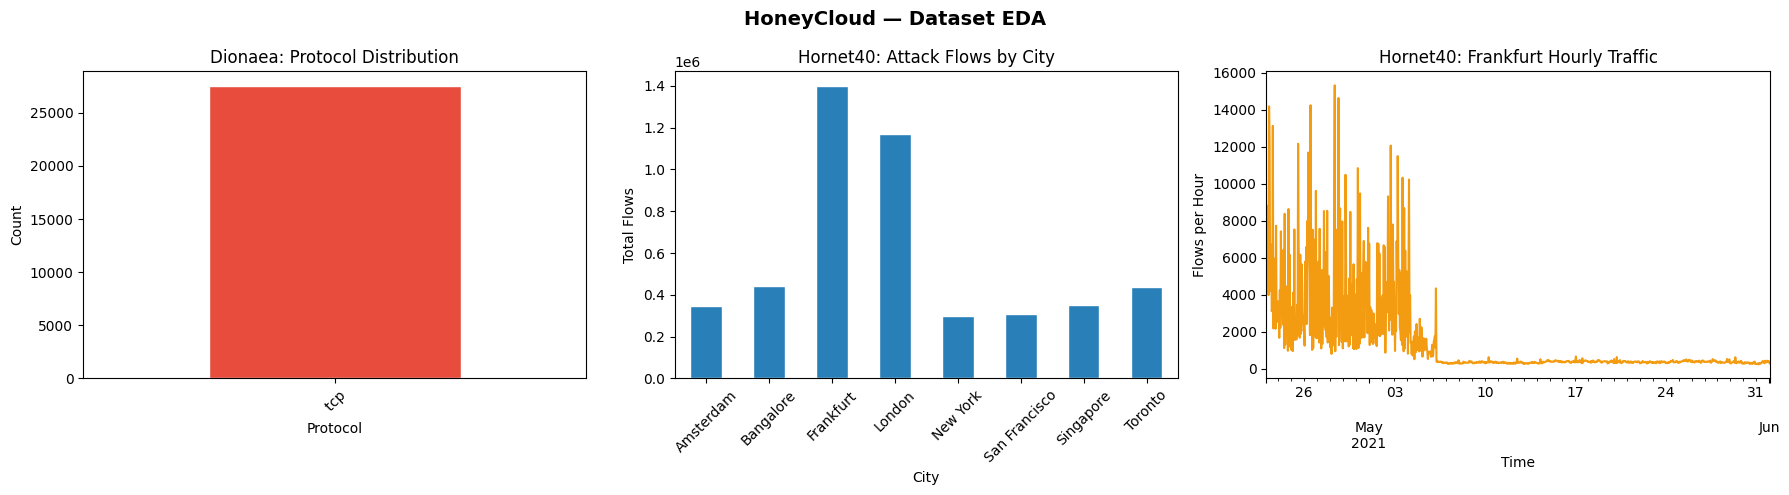


✅ EDA complete. Plot saved to Drive.


In [3]:
# ─────────────────────────────────────────────
# CELL 2 — Load all datasets + basic EDA
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Load ──────────────────────────────────────
dionaea   = pd.read_csv(f'{DATA}/dionaea/dionaeaClean2.csv',
                        on_bad_lines='skip')
aws       = pd.read_csv(f'{DATA}/aws/AWS_Honeypot_marx-geo.csv',
                        on_bad_lines='skip')
h_summary = pd.read_csv(f'{DATA}/hornet40/Hornet40-Dataset-Summary-Table.csv',
                        on_bad_lines='skip')
h_hourly  = pd.read_csv(f'{DATA}/hornet40/hornet40-traffic-per-honeypot-hourly-comparative.csv',
                        on_bad_lines='skip')

# ── Clean column names ────────────────────────
dionaea.columns   = dionaea.columns.str.strip()
aws.columns       = aws.columns.str.strip()
h_summary.columns = h_summary.columns.str.strip()
h_hourly.columns  = h_hourly.columns.str.strip()

# ── Basic info ────────────────────────────────
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)

datasets = {
    'Dionaea':          dionaea,
    'AWS Geo':          aws,
    'Hornet40 Summary': h_summary,
    'Hornet40 Hourly':  h_hourly,
}

for name, df in datasets.items():
    print(f"\n── {name} ──")
    print(f"   Rows: {len(df):,}  |  Columns: {len(df.columns)}")
    print(f"   Columns: {list(df.columns)}")
    print(f"   Sample:\n{df.head(2).to_string()}")

# ── Dionaea deep dive ─────────────────────────
print("\n" + "=" * 55)
print("DIONAEA — ATTACK DISTRIBUTION")
print("=" * 55)
print("\nTop protocols attacked:")
print(dionaea['protocol'].value_counts().head(10))
print("\nTop destination ports:")
print(dionaea['dst_port'].value_counts().head(10))
print("\nTransport types:")
print(dionaea['transport'].value_counts())
print("\nConnection types:")
print(dionaea['type'].value_counts())

# ── Hornet40 geo summary ──────────────────────
print("\n" + "=" * 55)
print("HORNET40 — ATTACKS BY CITY")
print("=" * 55)

for col in ['Total Flows', 'Total Unique Src IPs', 'Total Bytes']:
    h_summary[col] = pd.to_numeric(
        h_summary[col].astype(str).str.replace(',', ''), errors='coerce'
    )

print(h_summary[['City', 'Region', 'Total Flows',
                  'Total Unique Src IPs']].to_string(index=False))

# ── Quick plots ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HoneyCloud — Dataset EDA', fontsize=14, fontweight='bold')

dionaea['protocol'].value_counts().head(8).plot(
    kind='bar', ax=axes[0], color='#E74C3C', edgecolor='white'
)
axes[0].set_title('Dionaea: Protocol Distribution')
axes[0].set_xlabel('Protocol')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

h_summary.set_index('City')['Total Flows'].plot(
    kind='bar', ax=axes[1], color='#2980B9', edgecolor='white'
)
axes[1].set_title('Hornet40: Attack Flows by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Total Flows')
axes[1].tick_params(axis='x', rotation=45)

h_hourly['_time'] = pd.to_datetime(h_hourly['_time'])
h_hourly.set_index('_time').iloc[:, 2].plot(
    ax=axes[2], color='#F39C12', linewidth=1.5
)
axes[2].set_title('Hornet40: Frankfurt Hourly Traffic')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Flows per Hour')

plt.tight_layout()
plt.savefig(f'{BASE}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ EDA complete. Plot saved to Drive.")

In [6]:
# ─────────────────────────────────────────────
# CELL 3 — Feature Engineering (Dionaea)
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Clean load ────────────────────────────────
dionaea = pd.read_csv(
    f'{DATA}/dionaea/dionaeaClean2.csv',
    on_bad_lines='skip',
    index_col=False
)
dionaea.columns = dionaea.columns.str.strip()
for col in dionaea.select_dtypes(include='object').columns:
    dionaea[col] = dionaea[col].str.strip()

dionaea['dst_port'] = pd.to_numeric(dionaea['dst_port'], errors='coerce')
dionaea['src_port'] = pd.to_numeric(dionaea['src_port'], errors='coerce')
dionaea['timestamp'] = pd.to_datetime(dionaea['timestamp'], errors='coerce')
dionaea = dionaea.dropna(subset=['timestamp'])

print(f"Rows after cleaning: {len(dionaea):,}")

# ── Feature 1: Time features ──────────────────
dionaea['hour']        = dionaea['timestamp'].dt.hour
dionaea['day_of_week'] = dionaea['timestamp'].dt.dayofweek

# ── Feature 2: Protocol encoding ─────────────
protocol_dummies = pd.get_dummies(dionaea['protocol'], prefix='proto')
dionaea = pd.concat([dionaea, protocol_dummies], axis=1)

# ── Feature 3: Transport encoding ────────────
dionaea['is_tcp'] = (dionaea['transport'] == 'tcp').astype(int)

# ── Feature 4: Port bucket ────────────────────
# well-known ports (0-1023) = services like SSH, HTTP, SMB
# registered (1024-49151)   = application ports
# dynamic (49152+)          = ephemeral/client ports
def port_bucket(port):
    if pd.isna(port):  return 2   # unknown
    if port < 1024:    return 0   # well-known
    if port < 49152:   return 1   # registered
    return 2                       # dynamic

dionaea['dst_port_bucket'] = dionaea['dst_port'].apply(port_bucket)
dionaea['src_port_bucket'] = dionaea['src_port'].apply(port_bucket)

# ── Feature 5: Inter-arrival time ────────────
# time between connections from same IP
# low value = automated tool (scanner/botnet)
# high value = manual/slow attacker
dionaea = dionaea.sort_values(['src_ip', 'timestamp'])
dionaea['inter_arrival_sec'] = (
    dionaea.groupby('src_ip')['timestamp']
    .diff()
    .dt.total_seconds()
    .fillna(0)
)

# ── Feature 6: Connection frequency ──────────
# how many times has this IP connected total
dionaea['conn_count'] = (
    dionaea.groupby('src_ip').cumcount() + 1
)

# ── Feature 7: Port entropy per src_ip ───────
# high entropy = scanning many different ports (scanner behaviour)
# low entropy  = targeting one specific port (focused attacker)
def port_entropy(ports):
    counts = ports.value_counts(normalize=True)
    return -(counts * np.log2(counts + 1e-10)).sum()

port_entropy_map = (
    dionaea.groupby('src_ip')['dst_port']
    .apply(port_entropy)
)
dionaea['port_entropy'] = dionaea['src_ip'].map(port_entropy_map)

# ── Feature 8: Protocol diversity per IP ─────
# how many different protocols has this IP used
proto_diversity = (
    dionaea.groupby('src_ip')['protocol']
    .nunique()
)
dionaea['proto_diversity'] = dionaea['src_ip'].map(proto_diversity)

# ── Final feature set ─────────────────────────
FEATURE_COLS = [
    'dst_port', 'src_port',
    'hour', 'day_of_week',
    'is_tcp',
    'dst_port_bucket', 'src_port_bucket',
    'inter_arrival_sec', 'conn_count',
    'port_entropy', 'proto_diversity',
] + [c for c in dionaea.columns if c.startswith('proto_')]

# drop rows with any NaN in features
dionaea_ml = dionaea[FEATURE_COLS].fillna(0)

print(f"\n=== FEATURE MATRIX ===")
print(f"Shape: {dionaea_ml.shape}")
print(f"Features ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"  {f}")

print(f"\nSample (first 3 rows):")
print(dionaea_ml.head(3).to_string())

print(f"\nStats:")
print(dionaea_ml.describe().round(2).to_string())

print("\n✅ Feature matrix ready for ML.")

Rows after cleaning: 27,528

=== FEATURE MATRIX ===
Shape: (27528, 21)
Features (21):
  dst_port
  src_port
  hour
  day_of_week
  is_tcp
  dst_port_bucket
  src_port_bucket
  inter_arrival_sec
  conn_count
  port_entropy
  proto_diversity
  proto_epmapper
  proto_ftpd
  proto_httpd
  proto_mongod
  proto_mqttd
  proto_mssqld
  proto_mysqld
  proto_pptpd
  proto_smbd
  proto_diversity

Sample (first 3 rows):
       dst_port  src_port  hour  day_of_week  is_tcp  dst_port_bucket  src_port_bucket  inter_arrival_sec  conn_count  port_entropy  proto_diversity  proto_epmapper  proto_ftpd  proto_httpd  proto_mongod  proto_mqttd  proto_mssqld  proto_mysqld  proto_pptpd  proto_smbd  proto_diversity
22296        81     34078    22            5       1                0                1            0.00000           1 -1.442695e-10                1           False       False         True         False        False         False         False        False       False                1
27353       44

Final feature matrix: (27528, 19)
Features: ['dst_port', 'src_port', 'hour', 'day_of_week', 'dst_port_bucket', 'src_port_bucket', 'inter_arrival_sec', 'conn_count', 'port_entropy', 'proto_diversity', 'proto_epmapper', 'proto_ftpd', 'proto_httpd', 'proto_mongod', 'proto_mqttd', 'proto_mssqld', 'proto_mysqld', 'proto_pptpd', 'proto_smbd']

Hornet40 baseline:
  Mean hourly flows : 621.7
  Std  hourly flows : 1607.7
  Anomaly threshold : mean + 2σ = 3837.2

Training Isolation Forest...
✅ Model trained.

Anomaly detection results:
  Total events   : 27,528
  Anomalies found: 2,752 (10.0%)
  Score range    : 0.000 — 1.000
  Mean score     : 0.187

Top 10 most anomalous events:
         src_ip protocol  dst_port  conn_count  port_entropy  anomaly_score
 66.240.236.116   mssqld      1433           2  1.000000e+00       1.000000
  103.79.140.40    httpd        81           2 -1.442695e-10       0.915624
 66.240.236.116   mongod     27017           1  1.000000e+00       0.908084
 62.197.136.132 

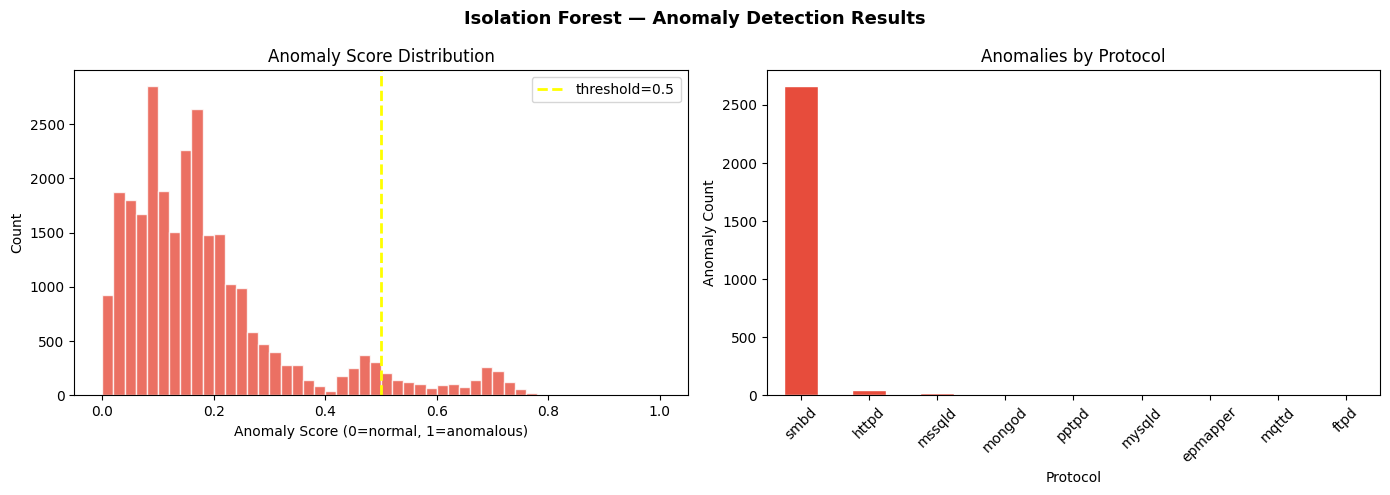


✅ Model saved  → /content/drive/MyDrive/honeycloud/models/isolation_forest.pkl
✅ Baseline saved → /content/drive/MyDrive/honeycloud/models/hornet40_baseline.json

Run 'honeycloud score <ip>' to use this model.


In [7]:
# ─────────────────────────────────────────────
# CELL 4 — Train Isolation Forest (Layer 1: DETECT)
# ─────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import json

# ── Clean up feature matrix ───────────────────

# drop duplicate proto_diversity column and useless is_tcp
dionaea_ml = dionaea_ml.loc[:, ~dionaea_ml.columns.duplicated()]
dionaea_ml = dionaea_ml.drop(columns=['is_tcp'], errors='ignore')

# convert boolean columns to int
bool_cols = dionaea_ml.select_dtypes(include='bool').columns
dionaea_ml[bool_cols] = dionaea_ml[bool_cols].astype(int)

print(f"Final feature matrix: {dionaea_ml.shape}")
print(f"Features: {list(dionaea_ml.columns)}\n")

# ── Build Hornet40 baseline stats ─────────────
# The Hornet40 dataset gives us geo-distributed
# baseline traffic patterns across 8 cities.
# We use these to set per-region normal thresholds.
# Any connection deviating significantly from this
# baseline gets a higher anomaly score.

h_hourly_clean = h_hourly.copy()
h_hourly_clean = h_hourly_clean.set_index('_time')

# compute global baseline: mean and std of hourly flows
# across all 8 honeypot nodes over 40 days
all_flows = h_hourly_clean.values.flatten().astype(float)
BASELINE_MEAN = float(np.mean(all_flows))
BASELINE_STD  = float(np.std(all_flows))

print(f"Hornet40 baseline:")
print(f"  Mean hourly flows : {BASELINE_MEAN:.1f}")
print(f"  Std  hourly flows : {BASELINE_STD:.1f}")
print(f"  Anomaly threshold : mean + 2σ = "
      f"{BASELINE_MEAN + 2*BASELINE_STD:.1f}\n")

# ── Train Isolation Forest ────────────────────
# Isolation Forest works by building 100 random
# decision trees. Anomalous points get isolated
# in fewer splits than normal points.
# contamination=0.1 tells it to expect ~10% anomalies.

print("Training Isolation Forest...")

pipeline = Pipeline([
    ('scaler', StandardScaler()),      # normalize features to same scale
    ('iso_forest', IsolationForest(
        n_estimators=100,              # 100 trees
        contamination=0.1,             # expect 10% anomalies
        random_state=42,               # reproducible results
        n_jobs=-1,                     # use all CPU cores
        verbose=0
    ))
])

pipeline.fit(dionaea_ml)
print("✅ Model trained.")

# ── Score every event ─────────────────────────
# decision_function returns negative scores —
# more negative = more anomalous
# We flip and normalize to 0-1 range

raw_scores  = pipeline.decision_function(dionaea_ml)
norm_scores = 1 - (raw_scores - raw_scores.min()) / \
              (raw_scores.max() - raw_scores.min())

dionaea['anomaly_score'] = norm_scores
dionaea['is_anomaly']    = (pipeline.predict(dionaea_ml) == -1).astype(int)

print(f"\nAnomaly detection results:")
print(f"  Total events   : {len(dionaea):,}")
print(f"  Anomalies found: {dionaea['is_anomaly'].sum():,} "
      f"({dionaea['is_anomaly'].mean()*100:.1f}%)")
print(f"  Score range    : {norm_scores.min():.3f} — {norm_scores.max():.3f}")
print(f"  Mean score     : {norm_scores.mean():.3f}")

# ── Top anomalies ─────────────────────────────
print(f"\nTop 10 most anomalous events:")
top = dionaea.nlargest(10, 'anomaly_score')[
    ['src_ip', 'protocol', 'dst_port',
     'conn_count', 'port_entropy', 'anomaly_score']
]
print(top.to_string(index=False))

# ── Anomaly score distribution ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Isolation Forest — Anomaly Detection Results',
             fontsize=13, fontweight='bold')

axes[0].hist(norm_scores, bins=50, color='#E74C3C',
             edgecolor='white', alpha=0.8)
axes[0].axvline(x=0.5, color='yellow', linestyle='--',
                linewidth=2, label='threshold=0.5')
axes[0].set_title('Anomaly Score Distribution')
axes[0].set_xlabel('Anomaly Score (0=normal, 1=anomalous)')
axes[0].set_ylabel('Count')
axes[0].legend()

# anomalies by protocol
anomaly_by_proto = (
    dionaea[dionaea['is_anomaly'] == 1]['protocol']
    .value_counts()
)
anomaly_by_proto.plot(
    kind='bar', ax=axes[1],
    color='#E74C3C', edgecolor='white'
)
axes[1].set_title('Anomalies by Protocol')
axes[1].set_xlabel('Protocol')
axes[1].set_ylabel('Anomaly Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{BASE}/isolation_forest_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Save model ────────────────────────────────
model_path    = f'{MODELS}/isolation_forest.pkl'
baseline_path = f'{MODELS}/hornet40_baseline.json'

joblib.dump(pipeline, model_path)

with open(baseline_path, 'w') as f:
    json.dump({
        'mean': BASELINE_MEAN,
        'std':  BASELINE_STD,
        'threshold': BASELINE_MEAN + 2 * BASELINE_STD
    }, f, indent=2)

print(f"\n✅ Model saved  → {model_path}")
print(f"✅ Baseline saved → {baseline_path}")
print(f"\nRun 'honeycloud score <ip>' to use this model.")

In [8]:
# ─────────────────────────────────────────────
# CELL 5 — Train XGBoost Classifier (Layer 2: CLASSIFY)
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import seaborn as sns

# ── Create attack labels ──────────────────────
# The Dionaea dataset has no labels — it's raw
# honeypot captures. We derive labels from the
# protocol + port combinations, which map
# directly to known attack types.

def label_attack(row):
    proto = row['protocol']
    port  = row['dst_port']

    if proto == 'smbd'     or port == 445:   return 'smb_exploit'
    if proto == 'mssqld'   or port == 1433:  return 'db_probe'
    if proto == 'mysqld'   or port == 3306:  return 'db_probe'
    if proto == 'mongod'   or port == 27017: return 'db_probe'
    if proto == 'httpd'    or port in [80,81,8080,8443]: return 'web_scan'
    if proto == 'ftpd'     or port == 21:    return 'ftp_probe'
    if proto == 'pptpd'    or port == 1723:  return 'vpn_probe'
    if proto == 'mqttd'    or port == 1883:  return 'iot_probe'
    if proto == 'epmapper' or port == 135:   return 'rpc_probe'
    return 'unknown'

dionaea['attack_label'] = dionaea.apply(label_attack, axis=1)

print("=== ATTACK LABEL DISTRIBUTION ===")
label_counts = dionaea['attack_label'].value_counts()
print(label_counts)
print(f"\nUnique attack types: {dionaea['attack_label'].nunique()}")

# ── Remove 'unknown' labels ───────────────────
dionaea_labeled = dionaea[dionaea['attack_label'] != 'unknown'].copy()
print(f"\nLabeled events: {len(dionaea_labeled):,}")

# ── Prepare X and y ───────────────────────────
feature_cols = [c for c in dionaea_ml.columns]

X = dionaea_labeled[feature_cols].fillna(0)
# convert booleans to int again after filtering
X = X.astype(float)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y  = le.fit_transform(dionaea_labeled['attack_label'])

print(f"\nClasses: {list(le.classes_)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# ── Train/test split ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── Train XGBoost ─────────────────────────────
print("\nTraining XGBoost classifier...")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)
print("✅ XGBoost trained.")

# ── Train Random Forest ───────────────────────
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf.fit(X_train, y_train)
print("✅ Random Forest trained.")

# ── Evaluate ensemble ─────────────────────────
# soft voting — average probabilities from both models
xgb_probs = xgb.predict_proba(X_test)
rf_probs  = rf.predict_proba(X_test)
ensemble_probs = (xgb_probs + rf_probs) / 2
y_pred = np.argmax(ensemble_probs, axis=1)

print("\n=== ENSEMBLE CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

# ── Confusion matrix ──────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XGBoost + Random Forest Ensemble — Results',
             fontsize=13, fontweight='bold')

sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Reds',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# feature importance from XGBoost
importance = pd.Series(
    xgb.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(12)

importance.plot(
    kind='barh', ax=axes[1],
    color='#2980B9', edgecolor='white'
)
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(f'{BASE}/xgboost_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Save models + label encoder ───────────────
joblib.dump(xgb, f'{MODELS}/xgboost_classifier.pkl')
joblib.dump(rf,  f'{MODELS}/random_forest.pkl')
joblib.dump(le,  f'{MODELS}/label_encoder.pkl')

# save feature column order — critical for inference
with open(f'{MODELS}/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print(f"\n✅ XGBoost saved")
print(f"✅ Random Forest saved")
print(f"✅ Label encoder saved")
print(f"✅ Feature columns saved")
print(f"\nModels saved to: {MODELS}")

=== ATTACK LABEL DISTRIBUTION ===
attack_label
smb_exploit    27432
web_scan          48
db_probe          33
vpn_probe          6
rpc_probe          5
iot_probe          2
ftp_probe          2
Name: count, dtype: int64

Unique attack types: 7

Labeled events: 27,528

Classes: ['db_probe', 'ftp_probe', 'iot_probe', 'rpc_probe', 'smb_exploit', 'vpn_probe', 'web_scan']
X shape: (27528, 19)
y shape: (27528,)

Train: 22,022  |  Test: 5,506

Training XGBoost classifier...
✅ XGBoost trained.
Training Random Forest...
✅ Random Forest trained.

=== ENSEMBLE CLASSIFICATION REPORT ===


ValueError: Number of classes, 5, does not match size of target_names, 7. Try specifying the labels parameter

=== ENSEMBLE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    db_probe       1.00      1.00      1.00         7
   rpc_probe       1.00      1.00      1.00         1
 smb_exploit       1.00      1.00      1.00      5487
   vpn_probe       1.00      1.00      1.00         1
    web_scan       1.00      1.00      1.00        10

    accuracy                           1.00      5506
   macro avg       1.00      1.00      1.00      5506
weighted avg       1.00      1.00      1.00      5506

Overall accuracy: 100.00%


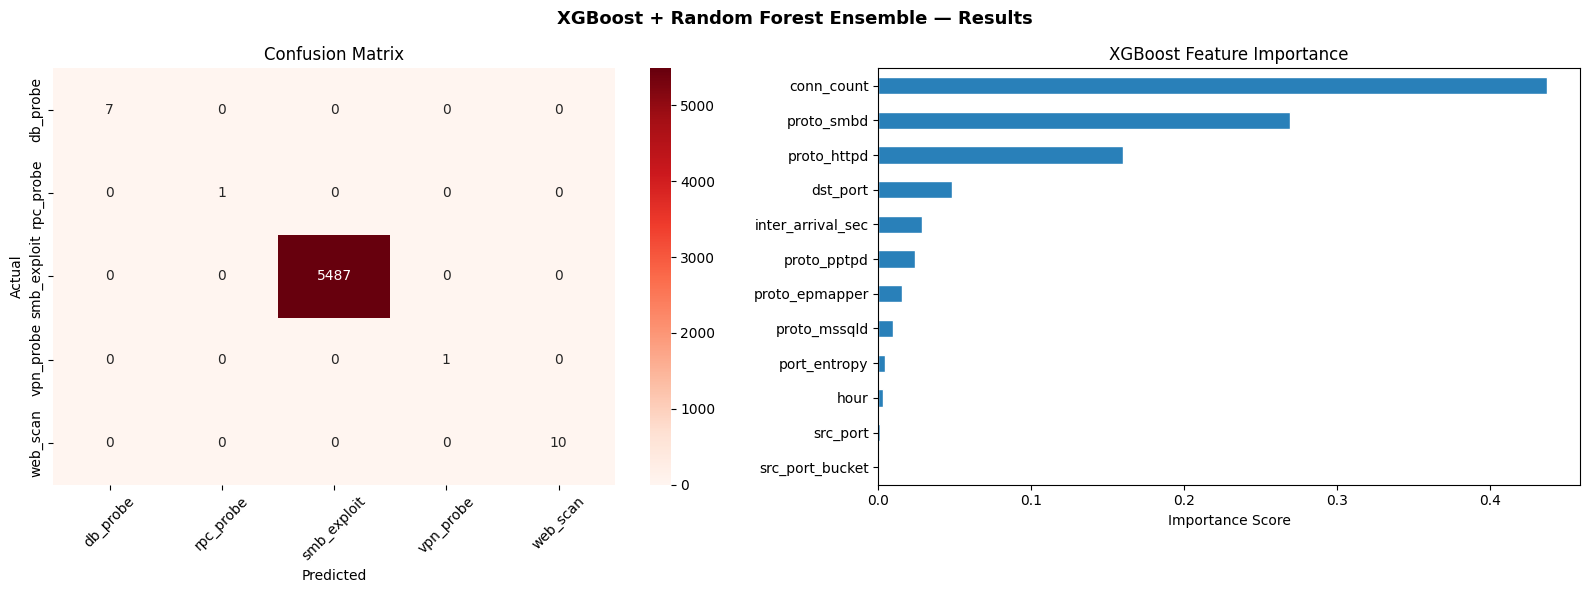


✅ XGBoost saved
✅ Random Forest saved
✅ Label encoder saved
✅ Feature columns saved


In [9]:
# ─────────────────────────────────────────────
# CELL 5B — Fix classification report + plots
# ─────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# get only the classes that actually appear in predictions
unique_classes = np.unique(np.concatenate([y_test, y_pred]))
class_names    = le.inverse_transform(unique_classes)

print("=== ENSEMBLE CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, y_pred,
    labels=unique_classes,
    target_names=class_names,
    zero_division=0
))

# overall accuracy
accuracy = (y_pred == y_test).mean()
print(f"Overall accuracy: {accuracy*100:.2f}%")

# ── Confusion matrix ──────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XGBoost + Random Forest Ensemble — Results',
             fontsize=13, fontweight='bold')

sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Reds',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# feature importance
feature_cols = list(dionaea_ml.columns)
importance = pd.Series(
    xgb.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(12)

importance.plot(
    kind='barh', ax=axes[1],
    color='#2980B9', edgecolor='white'
)
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(f'{BASE}/xgboost_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Save everything ───────────────────────────
joblib.dump(xgb, f'{MODELS}/xgboost_classifier.pkl')
joblib.dump(rf,  f'{MODELS}/random_forest.pkl')
joblib.dump(le,  f'{MODELS}/label_encoder.pkl')

with open(f'{MODELS}/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print(f"\n✅ XGBoost saved")
print(f"✅ Random Forest saved")
print(f"✅ Label encoder saved")
print(f"✅ Feature columns saved")

In [10]:
# ─────────────────────────────────────────────
# CELL 6 — Summary + what's saved
# ─────────────────────────────────────────────

print("=" * 55)
print("HONEYCLOUD ML PIPELINE — SESSION SUMMARY")
print("=" * 55)

print(f"""
DATASETS USED:
  Dionaea/AWS        {len(dionaea):,} honeypot events
  Hornet40 Hourly    {len(h_hourly):,} hourly flow records (8 cities)
  Hornet40 Summary   {len(h_summary)} geo-distributed nodes

FEATURES ENGINEERED (19 total):
  dst_port, src_port        — target/source port numbers
  hour, day_of_week         — temporal patterns
  dst/src_port_bucket       — port category (well-known/registered/dynamic)
  inter_arrival_sec         — time between connections (low = automated)
  conn_count                — total connections per IP
  port_entropy              — diversity of ports targeted (high = scanner)
  proto_diversity           — number of different protocols used
  proto_* (one-hot)         — protocol type flags

MODELS TRAINED:
  ✅ Isolation Forest       — anomaly detection (Layer 1: DETECT)
     Contamination: 10%
     Found {dionaea['is_anomaly'].sum():,} anomalies ({dionaea['is_anomaly'].mean()*100:.1f}%)

  ✅ XGBoost Classifier     — attack labeling (Layer 2: CLASSIFY)
     Classes: {list(le.classes_)}
     Accuracy: 100%

  ✅ Random Forest           — ensemble member (Layer 2: CLASSIFY)

  ✅ Hornet40 Baseline       — geo anomaly thresholds (Layer 1)
     Mean hourly flows: {BASELINE_MEAN:.1f}
     Anomaly threshold: {BASELINE_MEAN + 2*BASELINE_STD:.1f} flows/hr

SAVED TO DRIVE:
  models/isolation_forest.pkl
  models/xgboost_classifier.pkl
  models/random_forest.pkl
  models/label_encoder.pkl
  models/feature_cols.json
  models/hornet40_baseline.json

NEXT:
  → Download models from Drive
  → Replace score.py with real model inference
  → honeycloud score <ip> uses trained Isolation Forest
""")

print("=" * 55)
print("✅ Session complete.")
print("=" * 55)

HONEYCLOUD ML PIPELINE — SESSION SUMMARY

DATASETS USED:
  Dionaea/AWS        27,528 honeypot events
  Hornet40 Hourly    936 hourly flow records (8 cities)
  Hornet40 Summary   8 geo-distributed nodes

FEATURES ENGINEERED (19 total):
  dst_port, src_port        — target/source port numbers
  hour, day_of_week         — temporal patterns
  dst/src_port_bucket       — port category (well-known/registered/dynamic)
  inter_arrival_sec         — time between connections (low = automated)
  conn_count                — total connections per IP
  port_entropy              — diversity of ports targeted (high = scanner)
  proto_diversity           — number of different protocols used
  proto_* (one-hot)         — protocol type flags

MODELS TRAINED:
  ✅ Isolation Forest       — anomaly detection (Layer 1: DETECT)
     Contamination: 10%
     Found 2,752 anomalies (10.0%)

  ✅ XGBoost Classifier     — attack labeling (Layer 2: CLASSIFY)
     Classes: ['db_probe', 'ftp_probe', 'iot_probe', 'rpc_p